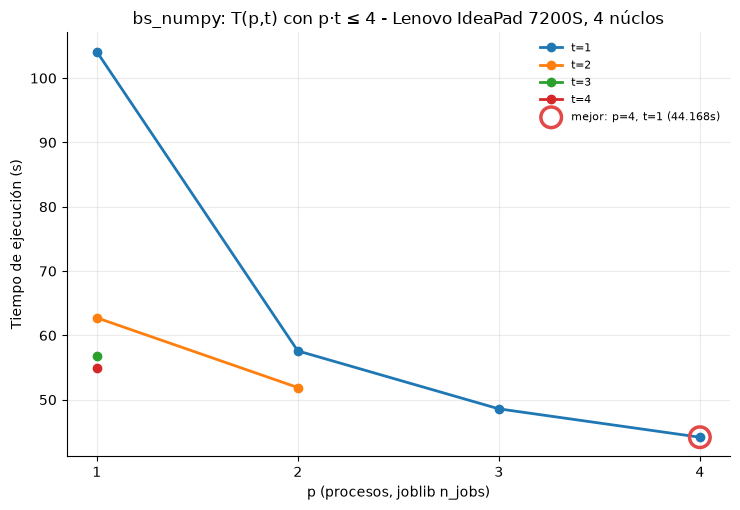

Mejor combinación: p=4, t=1 -> 44.168 s


In [4]:
import csv
import matplotlib.pyplot as plt

with open('i_results.csv', newline='') as f:
    rows = [
        {'p': int(row['p']), 't': int(row['t']), 'tiempo_s': float(row['tiempo_s'])}
        for row in csv.DictReader(f)
    ]

pmax = max(row['p'] * row['t'] for row in rows)
fig, ax = plt.subplots(figsize=(7.5, 5.2))
ts_present = sorted({row['t'] for row in rows})

for t in ts_present:
    sub = sorted((row for row in rows if row['t'] == t), key=lambda row: row['p'])
    ax.plot(
        [row['p'] for row in sub],
        [row['tiempo_s'] for row in sub],
        marker='o',
        linewidth=2,
        markersize=6,
        label=f't={t}'
    )

best = min(rows, key=lambda row: row['tiempo_s'])
ax.scatter(
    [best['p']],
    [best['tiempo_s']],
    s=220,
    facecolors='none',
    edgecolors='#e34948',
    linewidths=2.5,
    zorder=5,
    label=f"mejor: p={best['p']}, t={best['t']} ({best['tiempo_s']}s)"
)

ax.set_xlabel('p (procesos, joblib n_jobs)')
ax.set_ylabel('Tiempo de ejecución (s)')
ax.set_title(f'bs_numpy: T(p,t) con p·t ≤ {pmax} - Lenovo IdeaPad 7200S, 4 núclos')
ax.set_xticks(range(1, max(row['p'] for row in rows) + 1))
ax.legend(loc='upper right', fontsize=8, frameon=False)
ax.grid(alpha=0.25)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()
print(f"Mejor combinación: p={best['p']}, t={best['t']} -> {best['tiempo_s']} s")

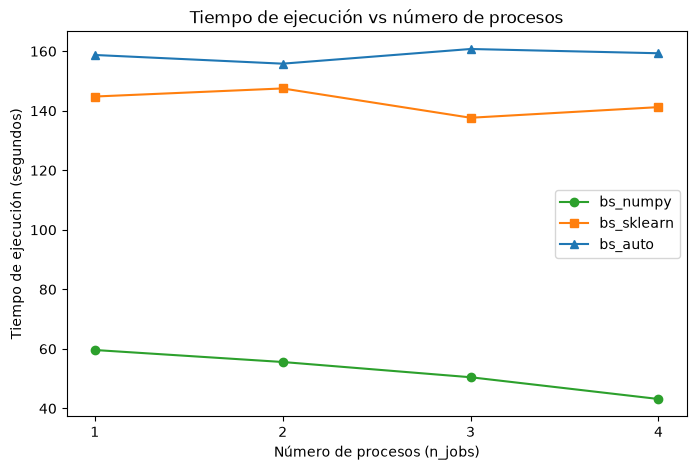

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title('Tiempo de ejecución vs número de procesos')
ax.set_ylabel('Tiempo de ejecución (segundos)')
ax.set_xlabel('Número de procesos (n_jobs)')

numpy_times = [59.62, 55.59, 50.47, 43.16]
sklearn_times = [144.78, 147.50, 137.65, 141.22]
auto_times = [158.74, 155.82, 160.75, 159.32]

n_jobs = [1, 2, 3, 4]
ax.plot(n_jobs, numpy_times, marker='o', linestyle='-', color='C2')
ax.plot(n_jobs, sklearn_times, marker='s', linestyle='-', color='C1')
ax.plot(n_jobs, auto_times, marker='^', linestyle='-', color='C0')
ax.legend(['bs_numpy', 'bs_sklearn', 'bs_auto'])
plt.xticks(n_jobs)
plt.show()